# Compute/Vision Validation — Real YOLO/OpenCV Smart-Camera Trace
 This notebook is used compare the real Raspberry Pi YOLO/OpenCV video-object-detection trace against synthetic:

- NVIDIA Jetson Nano
- Drone Flight Controller
- Ring Doorbell

This validates a real Pi-executable smart-camera workload, not proprietary commercial firmware.

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings("ignore")

## We upload real YOLO perf CSV and synthetic CSV files

In [ ]:
uploaded = files.upload()
print("Uploaded:")
for f in uploaded:
    print("-", f)

Saving drone_flight_controller_hpc_20251016_210745.csv to drone_flight_controller_hpc_20251016_210745.csv
Saving nvidia_jetson_nano_hpc_20251013_130355.csv to nvidia_jetson_nano_hpc_20251013_130355.csv
Saving real_yolo_opencv_video_perf_30ms.csv to real_yolo_opencv_video_perf_30ms.csv
Saving ring_doorbell_hpc_20251014_114513.csv to ring_doorbell_hpc_20251014_114513.csv
Uploaded:
- drone_flight_controller_hpc_20251016_210745.csv
- nvidia_jetson_nano_hpc_20251013_130355.csv
- real_yolo_opencv_video_perf_30ms.csv
- ring_doorbell_hpc_20251014_114513.csv


##  Detect files

In [ ]:
def first_match(substrings):
    for sub in substrings:
        matches = [f for f in os.listdir() if sub.lower() in f.lower() and f.endswith(".csv")]
        if matches:
            return matches[0]
    return None

real_file = first_match(["real_yolo_opencv_video_perf", "real_yolo", "opencv", "smart_camera", "real_vision", "vision_perf"])

synthetic_files = {
    "NVIDIA Jetson Nano": first_match(["nvidia_jetson_nano", "jetson"]),
    "Drone Flight Controller": first_match(["drone_flight_controller", "drone"]),
    "Ring Doorbell": first_match(["ring_doorbell", "ring"])
}

print("Real file:", real_file)
for k,v in synthetic_files.items():
    print(k, "=>", v)

if real_file is None:
    raise FileNotFoundError("Upload the real YOLO/OpenCV perf CSV.")
missing = [k for k,v in synthetic_files.items() if v is None]
if missing:
    raise FileNotFoundError(f"Missing synthetic files: {missing}")

Real file: real_yolo_opencv_video_perf_30ms.csv
NVIDIA Jetson Nano => nvidia_jetson_nano_hpc_20251013_130355.csv
Drone Flight Controller => drone_flight_controller_hpc_20251016_210745.csv
Ring Doorbell => ring_doorbell_hpc_20251014_114513.csv


## Parse real `perf stat -x ';' -I 30` CSV

In [ ]:
def to_float(x):
    x = str(x).strip().replace(",", "")
    if x in ["", "<not counted>", "<not supported>", "not", "<not"]:
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

def parse_perf_csv(path):
    event_map = {
        "cycles": "cycles",
        "cpu-cycles": "cycles",
        "instructions": "instructions",
        "cache-references": "cache-references",
        "cache-misses": "cache-misses",
    }
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(";")] if ";" in line else line.split()
            if len(parts) < 3:
                continue
            t = to_float(parts[0])
            val = to_float(parts[1])
            event = None
            for p in parts:
                if p in event_map:
                    event = event_map[p]
                    break
            if event and not np.isnan(t) and not np.isnan(val):
                rows.append({"time_interval": t, "event": event, "value": val})
    long_df = pd.DataFrame(rows)
    if long_df.empty:
        raise ValueError("Could not parse perf rows. Check file format.")
    return long_df.pivot_table(index="time_interval", columns="event", values="value", aggfunc="sum").reset_index()

def convert_to_hw_schema(perf_df):
    out = pd.DataFrame()
    out["timestamp"] = perf_df["time_interval"]
    out["hw_cpu_cycles"] = pd.to_numeric(perf_df.get("cycles"), errors="coerce")
    out["hw_instructions_retired"] = pd.to_numeric(perf_df.get("instructions"), errors="coerce")
    out["hw_cache_references"] = pd.to_numeric(perf_df.get("cache-references"), errors="coerce")
    out["cache_misses_raw"] = pd.to_numeric(perf_df.get("cache-misses"), errors="coerce")
    out["hw_instructions_per_cycle"] = out["hw_instructions_retired"] / out["hw_cpu_cycles"].replace(0, np.nan)
    out["hw_cache_miss_rate"] = out["cache_misses_raw"] / out["hw_cache_references"].replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan).dropna()

def load_real(path):
    try:
        df = pd.read_csv(path)
        if "hw_cpu_cycles" in df.columns and "hw_instructions_per_cycle" in df.columns:
            print("Loaded preprocessed hw_* real file.")
            return df
    except Exception:
        pass
    print("Parsing raw perf output...")
    perf_df = parse_perf_csv(path)
    display(perf_df.head())
    return convert_to_hw_schema(perf_df)

real_clean = load_real(real_file)
print("Cleaned real shape:", real_clean.shape)
display(real_clean.head())

Parsing raw perf output...


event,time_interval,cache-misses,cache-references,cycles,instructions
0,0.030121,278110.0,8211005.0,27156215.0,20138831.0
1,0.061732,333454.0,10581555.0,34716785.0,24453942.0
2,0.091989,372634.0,9607131.0,33275991.0,21370164.0
3,0.122248,344927.0,11404518.0,33287247.0,27360197.0
4,0.152493,380052.0,10366710.0,34503882.0,22956377.0


Cleaned real shape: (1963, 7)


,timestamp,hw_cpu_cycles,hw_instructions_retired,hw_cache_references,cache_misses_raw,hw_instructions_per_cycle,hw_cache_miss_rate
0,0.030121,27156215.0,20138831.0,8211005.0,278110.0,0.741592,0.033870
1,0.061732,34716785.0,24453942.0,10581555.0,333454.0,0.704384,0.031513
2,0.091989,33275991.0,21370164.0,9607131.0,372634.0,0.642210,0.038787
3,0.122248,33287247.0,27360197.0,11404518.0,344927.0,0.821942,0.030245
4,0.152493,34503882.0,22956377.0,10366710.0,380052.0,0.665327,0.036661


## Load synthetic datasets and keep active rows

In [ ]:
def load_synth(path):
    df = pd.read_csv(path)
    if "workload_intensity" in df.columns:
        df = df[df["workload_intensity"] > 10].copy()
    for c in df.columns:
        if c.startswith("hw_"):
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.replace([np.inf, -np.inf], np.nan)

synthetic_data = {name: load_synth(path) for name, path in synthetic_files.items()}
for name, df in synthetic_data.items():
    print(name, df.shape)

NVIDIA Jetson Nano (19946, 30)
Drone Flight Controller (20000, 33)
Ring Doorbell (9473, 29)


## Select shared features

In [ ]:
candidate_features = [
    "hw_cpu_cycles",
    "hw_instructions_retired",
    "hw_cache_references",
    "hw_instructions_per_cycle",
    "hw_cache_miss_rate",
]

shared_features = [f for f in candidate_features if f in real_clean.columns and all(f in df.columns for df in synthetic_data.values())]
ratio_features = [f for f in ["hw_instructions_per_cycle", "hw_cache_miss_rate"] if f in shared_features]

print("Shared features:", shared_features)
print("Ratio features:", ratio_features)

assert len(shared_features) >= 2, "Too few shared features."
assert len(ratio_features) >= 1, "No ratio features available."

Shared features: ['hw_cpu_cycles', 'hw_instructions_retired', 'hw_cache_references', 'hw_instructions_per_cycle', 'hw_cache_miss_rate']
Ratio features: ['hw_instructions_per_cycle', 'hw_cache_miss_rate']


##Compute similarity and feature-level comparison

In [ ]:
def safe_cos(a,b):
    a = np.asarray(a, dtype=float).reshape(1,-1)
    b = np.asarray(b, dtype=float).reshape(1,-1)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return np.nan
    return float(cosine_similarity(a,b)[0,0])

def log_profile(df, feats):
    v = df[feats].mean().reindex(feats).fillna(0).astype(float).values
    return np.log1p(np.maximum(v, 0))

def raw_profile(df, feats):
    return df[feats].mean().reindex(feats).fillna(0).astype(float).values

real_log = log_profile(real_clean, shared_features)
real_ratio = raw_profile(real_clean, ratio_features)

sim_rows = []
comp_rows = []

for device, df in synthetic_data.items():
    synth_log = log_profile(df, shared_features)
    synth_ratio = raw_profile(df, ratio_features)

    sim_rows.append({
        "synthetic_device": device,
        "real_reference": "YOLO/OpenCV smart-camera workload",
        "log_mean_cosine_shared_features": safe_cos(real_log, synth_log),
        "ratio_only_cosine": safe_cos(real_ratio, synth_ratio),
        "real_rows": len(real_clean),
        "synthetic_active_rows": len(df)
    })

    for feat in shared_features:
        real_mean = real_clean[feat].mean()
        synth_mean = df[feat].mean()
        pct = np.nan if abs(real_mean) < 1e-12 else ((synth_mean - real_mean) / abs(real_mean)) * 100
        comp_rows.append({
            "synthetic_device": device,
            "feature": feat,
            "feature_type": "ratio/derived" if feat in ratio_features else "raw count",
            "real_mean": real_mean,
            "synthetic_mean": synth_mean,
            "percent_difference_vs_real": pct
        })

similarity_df = pd.DataFrame(sim_rows)
comparison_df = pd.DataFrame(comp_rows)

display(similarity_df.round(6))
display(comparison_df.round(6))

,synthetic_device,real_reference,log_mean_cosine_shared_features,ratio_only_cosine,real_rows,synthetic_active_rows
0,NVIDIA Jetson Nano,YOLO/OpenCV smart-camera workload,0.999011,0.999962,1963,19946
1,Drone Flight Controller,YOLO/OpenCV smart-camera workload,0.999076,0.999969,1963,20000
2,Ring Doorbell,YOLO/OpenCV smart-camera workload,0.998937,0.999999,1963,9473


,synthetic_device,feature,feature_type,real_mean,synthetic_mean,percent_difference_vs_real
0,NVIDIA Jetson Nano,hw_cpu_cycles,raw count,1.984777e+08,3.389216e+06,-98.292395
1,NVIDIA Jetson Nano,hw_instructions_retired,raw count,8.907358e+07,2.947510e+06,-96.690926
2,NVIDIA Jetson Nano,hw_cache_references,raw count,3.254089e+07,3.149070e+05,-99.032273
3,NVIDIA Jetson Nano,hw_instructions_per_cycle,ratio/derived,4.704870e-01,8.798060e-01,86.998909
4,NVIDIA Jetson Nano,hw_cache_miss_rate,ratio/derived,2.855900e-02,6.112300e-02,114.021640
5,Drone Flight Controller,hw_cpu_cycles,raw count,1.984777e+08,4.290858e+06,-97.838116
6,Drone Flight Controller,hw_instructions_retired,raw count,8.907358e+07,3.773734e+06,-95.763352
7,Drone Flight Controller,hw_cache_references,raw count,3.254089e+07,4.060903e+05,-98.752061
8,Drone Flight Controller,hw_instructions_per_cycle,ratio/derived,4.704870e-01,8.880340e-01,88.747733
9,Drone Flight Controller,hw_cache_miss_rate,ratio/derived,2.855900e-02,6.087800e-02,113.164283


## Interpretation summary

In [ ]:
summary_rows = []
for device in synthetic_data:
    sim = similarity_df[similarity_df.synthetic_device == device].iloc[0]
    sub = comparison_df[comparison_df.synthetic_device == device]
    raw_avg = sub[sub.feature_type == "raw count"]["percent_difference_vs_real"].abs().mean()
    ratio_avg = sub[sub.feature_type == "ratio/derived"]["percent_difference_vs_real"].abs().mean()
    rc = sim["ratio_only_cosine"]
    if rc >= 0.95:
        interpretation = "Strong behavioural support"
    elif rc >= 0.85:
        interpretation = "Moderate behavioural support"
    else:
        interpretation = "Weak behavioural support"
    summary_rows.append({
        "synthetic_device": device,
        "log_mean_cosine_shared_features": sim["log_mean_cosine_shared_features"],
        "ratio_only_cosine": rc,
        "avg_abs_percent_diff_raw_counts": raw_avg,
        "avg_abs_percent_diff_ratio_features": ratio_avg,
        "recommended_interpretation": interpretation
    })

interpretation_df = pd.DataFrame(summary_rows)
display(interpretation_df.round(6))

,synthetic_device,log_mean_cosine_shared_features,ratio_only_cosine,avg_abs_percent_diff_raw_counts,avg_abs_percent_diff_ratio_features,recommended_interpretation
0,NVIDIA Jetson Nano,0.999011,0.999962,98.005198,100.510275,Strong behavioural support
1,Drone Flight Controller,0.999076,0.999969,97.451177,100.956008,Strong behavioural support
2,Ring Doorbell,0.998937,0.999999,98.394134,88.062920,Strong behavioural support


## Ratio-feature boxplots

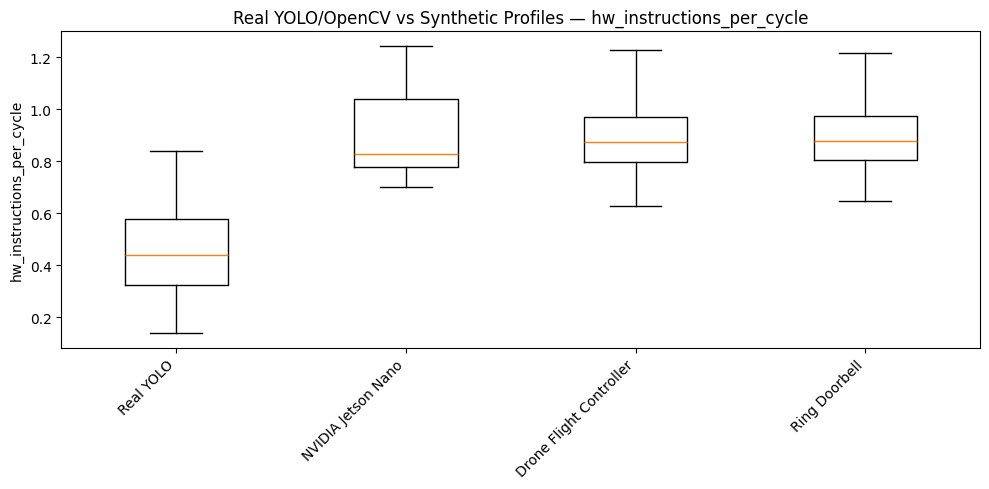

Saved: yolo_opencv_boxplot_hw_instructions_per_cycle.png


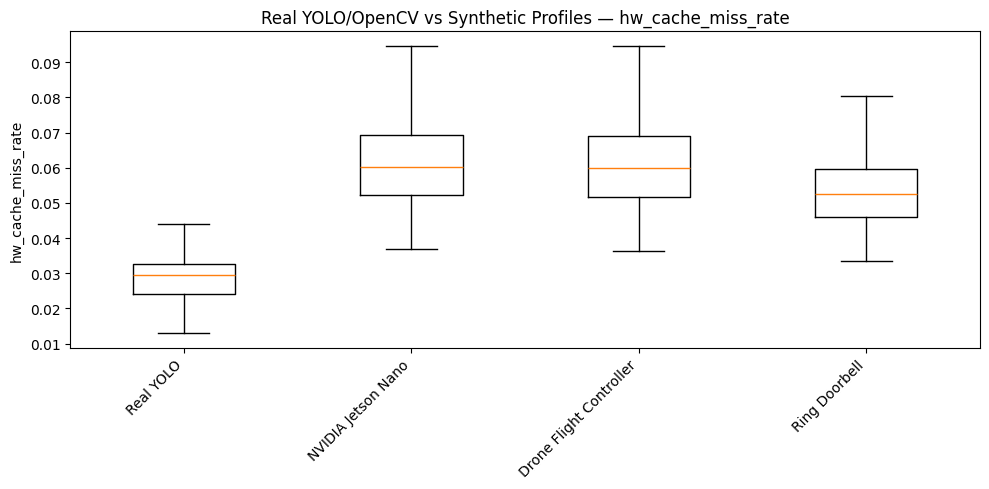

Saved: yolo_opencv_boxplot_hw_cache_miss_rate.png


In [ ]:
for feat in ratio_features:
    data = [real_clean[feat].dropna().values]
    labels = ["Real YOLO"]
    for device, df in synthetic_data.items():
        data.append(df[feat].dropna().values)
        labels.append(device)

    plt.figure(figsize=(10,5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(feat)
    plt.title(f"Real YOLO/OpenCV vs Synthetic Profiles — {feat}")
    plt.tight_layout()
    fname = f"yolo_opencv_boxplot_{feat}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fname)